<a href="https://colab.research.google.com/github/ChanggonSong/AI-Study/blob/main/Stochastic_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

확률적 경사 하강법을 이용한 분류 모델을 만들어 보자!

In [69]:
import pandas as pd
fish = pd.read_csv('https://bit.ly/fish_csv_data')

fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']].to_numpy()
fish_target = fish['Species'].to_numpy()

Species 열은 타깃 데이터이다.

In [70]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(fish_input, fish_target, random_state=42)

train_test_split()으로 훈련,테스트 세트 나누고,

In [71]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_input)

train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

훈련세트와 테스트 세트를 전처리 표준화했다.
이제 특성값의 스케일을 맞춘  train_scaled와 test_scaled 두 넘파이 배열을 준비됬다. 여기까지는 이전과 동일하다.

사이킷런에서 확률적 경사하강법을 제공하는 대표적인 분류용 클래스인 SGDClassifier을 사용해보자. sklearn.linear_model 패키지 아래에서 임포트하자.

SGDClassifier의 객체를 만들 때 2개의 매개변수를 지정한다.
먼저 여기서 loss='log_loss'로 지정하여 로지스틱 손실 함수를 지정했다.
그리고 max_iter은 수행할 에포크 횟수를 지정한다.

그리고 분류 모델이므로 훈련 세트와 테스트 세트에서의 정확도를 출력한다.

In [72]:
# 확률적 경사 하강법을 제공하는 분류용 클래스
from sklearn.linear_model import SGDClassifier

# loss : 손실 함수의 종류 지정, max_iter : 수행할 에포크 횟수
sc = SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.773109243697479
0.775


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


(위 코드를 실행하면 사이킷런은 모델이 충분히 수렴되지 않았다는 경고를 보낸다. 그러면 max_iter 매개변수의 값을 늘려주는 것이 좋다.)

출력된 훈련세트와 테스트 세트의 정확도가 낮다(과소적합으로도 볼 수 있다). 아마도 지정한 반복 횟수 10번이 부족했던 것 같다.

확률적 경사 하강법은 점진적인 학습이 가능하다. SGDClassifier 객체를 다시 만들지 않고 훈련한 모델 sc를 추가로 더 훈련해보자.

모델을 이어서 훈련할 때는 partial_fit() 메서드를 이용한다.이 메서드는 fit() 메서드와 사용법이 같지만, 호출할 때마다 1에포크씩 이어서 훈련할 수 있다.
(만약 다시 fit()을 사용하면 이전에 훈련한 것을 모두 버리고 다시 시작한다.)

In [73]:
sc.partial_fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.8151260504201681
0.85


**+** 위 SGDClassifier은 전달한 훈련 세트에서 1개씩 샘플을 꺼내어 경사 하강법 단계를 수행하는 확률적 경사 하강법이다!
SGDClassifier은 미니배치 경사 하강법이나 배치 경사 하강법을 제공하지 않는다.

아직 점수가 낮지만, 에포크를 한 번 더 실행하니 정확도가 향상되었다!!
이 모델을 여러 에포크에서 더 훈련해볼 필요가 있겠다.

그런데 얼마나 더 훈련해야 할까?

처음 모델처럼 적은 에포크 횟수로 훈련한다면 훈련 세트와 테스트 세트에 잘 맞지 않는 과소적합된 모델일 가능성이 높다.
하지만 반대로 많은 에포크 횟수로 훈련한 모델은 훈련 세트에 너무 잘 맞아 테스트 세트에는 오히려 점수가 나쁜 과대적합된 모델일 가능성이 높다.

## 에포크와 과대/과소적합

에포크 횟수가 적으면 모델이 훈련 세트를 덜 학습하고, 에포크 횟수가 많으면 모델이 훈련 세트를 많이 학습한다.

- 처음 모델처럼 **적은 에포크 횟수로 훈련**한다면 훈련 세트와 테스트 세트에 잘 맞지 않는 **과소적합**된 모델일 가능성이 높다.
- 하지만 반대로 **많은 에포크 횟수로 훈련**한 모델은 훈련 세트에 너무 잘 맞아 테스트 세트에는 오히려 점수가 나쁜 **과대적합**된 모델일 가능성이 높다.

> 위 그래프를 보면 훈련 세트 점수는 꾸준히 증가하지만, 테스트 점수는 어느 순간 감소한다.
바로 이 지점이 모델이 과대적합되기 시작하는 곳이다!
>
- 따라서 과대적합이 시작하기 전에 훈련을 멈추는 것을
**조기 종료 (early stopping)**라고 한다.

그럼 우리가 준비한 데이터셋으로 위와 같은 그래프를 그려보자.

- 이 예제에서는 `fit()` 메서드 대신  `partial_fit()` 메서드만 사용하여 적절한 에포크 횟수를 알아본다.
    - partial_fit() 메서드만 사용하려면, 훈련 세트에 있는 전체 클래스의 레이블을 partial_fit() 메서드에 전달해 주어야 한다.
    이를 위해 np.unique() 함수로 train_target에 있는 7개 생선의 목록을 만든다.
    - 또 에포크마다의 *훈련 세트와 테스트 세트에 대한 점수*를 기록하기 위해 2개의 리스트를 준비해준다.

In [74]:
import numpy as np
sc = SGDClassifier(loss='log_loss', random_state=42)
train_score = []
test_score = []
classes = np.unique(train_target) # 7개의 생선의 종류

- 300번의 에포크 동안 훈련을 반복해서 진행해보자.
    - 반복마다 훈련 세트와 테스트 세트의 점수를 계산하여 `train_score`, `test_score` 리스트에 추가한다.

In [75]:
for _ in range(0, 300) :
  sc.partial_fit(train_scaled, train_target, classes = classes)
  train_score.append(sc.score(train_scaled, train_target))
  test_score.append(sc.score(test_scaled, test_target))

파이썬의 _는 나중에 사용하지 않고 그냥 버리는 값을 넣어 두는 용도로  사용한다. 여기서는 0부터 299까지 반복 횟수를 임시 저장하기 위한 용도로 사용했다.

그럼 이제 300번의 에포크 동안 기록한 훈련 세트와 테스트 세트의 점수를 그래프로 그려보자.

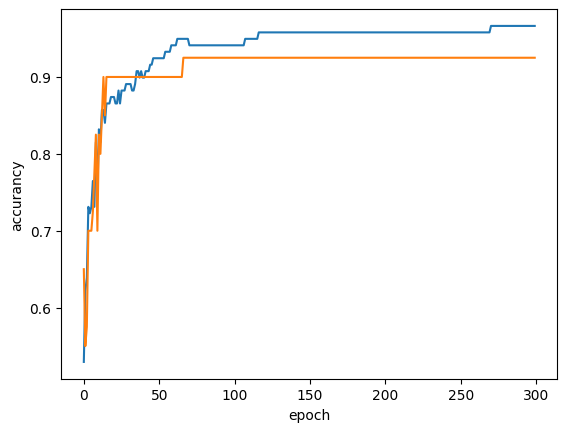

In [76]:
import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accurancy')
plt.show()

에포크 초기에는 과소적합되어 훈련 세트와 테스트 세트의 점수가 둘 다 낮은 것을 알 수 있다.

또 100 번째 epoch(에포크) 이후에는 훈련 세트와 테스트 세트의 점수가 조금씩 벌어지고 있는 것을 볼 수 있다.

- 이 모델의 경우 100 번째 에포크가 적절한 반복 횟수로 보인다.

그럼 이제 SGDClassifier의 반복 횟수를 100에 맞추고, 모델을 다시 훈련해보고,

In [77]:
sc = SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)

SGDClassifier(loss='log_loss', max_iter=100, random_state=42, tol=None)

그리고 최종적으로 훈련 세트와 테스트 세트의 점수를 출력해보자.

In [78]:
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925


- SGDClassifier은 일정 에포크 동안 성능이 향상되지 않으면 더 훈련하지 않고 자동으로 멈춘다.
- tol 매개변수에서 향상될 최솟값을 지정한다. 앞의 코드에서는 tol 매개변수를 None으로 지정하여 자동으로 멈추지 않고 max_iter=100 만큼 무조건 반복하도록 하였다.

- 확률적 경사 하강법을 사용한 분류 모델이 있다면 회귀 모델도 있나?

    네. SGDClassifier처럼 SGDRegressor가 바로 확률적 경사 하강법을 사용한 회귀 알고리즘을 제공한다!

### SGDClassifier의 loss 매개변수 - 힌지 손실

- 사실 loss 매개변수의 기본값은 ‘hinge’이다. **힌지 손실(hinge loss)**는
**서포트 벡터 머신(support vector machine)**이라 불리는 또 다른 머신러닝 알고리즘을 위한 손실 함수이다.
- 서포트 벡터 머신이 널리 사용하는 머신러닝 알고리즘 중 하나라는 점과 SGDClassifier가 여러 종류의 손실 함수를 loss 매개변수에 지정하여 다양한 머신러닝 알고리즘을 지원한다는 것은 기억하자.

간단한 예로  힌지 손실을 사용해 같은 반복 횟수 동안 모델을 훈련해보자.

In [79]:
sc = SGDClassifier(loss='hinge', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.9495798319327731
0.925
